# 산점도 그래프 : 데이터간 관계 표현

<Axes: xlabel='displ', ylabel='hwy'>

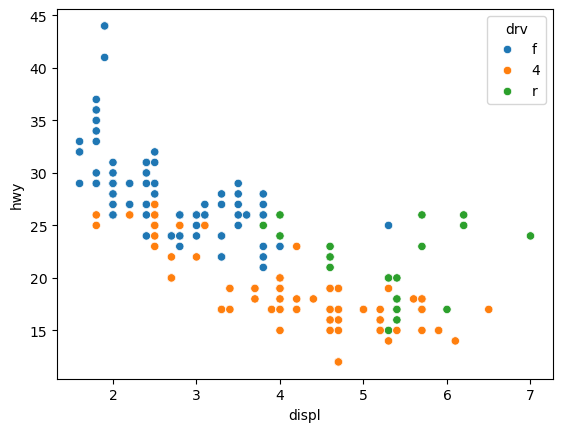

In [24]:
# 08-2 산점도 그래프 - sns.scatterplot 변수간 관계 표현
import pandas as pd
import seaborn as sns

mpg = pd.read_csv('mpg.csv')
# 1. 기본출력
# sns.scatterplot(data=mpg, x='displ', y='hwy')
# 2. x축 , y축 범위설정
# sns.scatterplot(data=mpg, x='displ', y='hwy').set(xlim=[3,6],ylim=[10,30])
# 3. 종류별로 색깔바꾸기
sns.scatterplot(data=mpg, x='displ',y='hwy',hue='drv')

[(1.0, 500000.0), (1.0, 10000.0)]

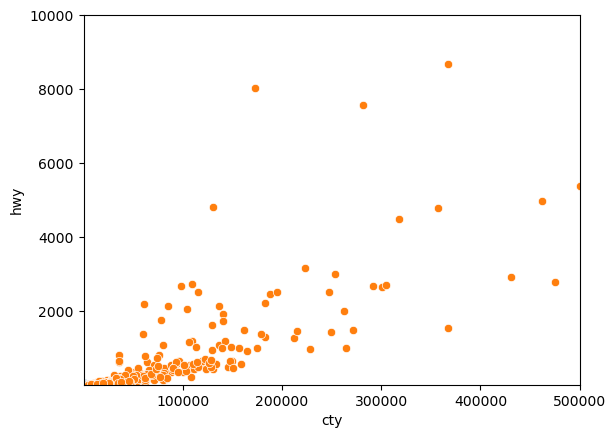

In [25]:
# p204. 혼자서 해보기
# Q1. mpg데이터의 cty와 hwy와의 상관관계를 알아보려합니다. x축은 cty, y축은 hwy로 된 산점도그래프 출력
import pandas as pd
import seaborn as sns
mpg = pd.read_csv('mpg.csv')
sns.scatterplot(data=mpg, x='cty',y='hwy')

# Q2. midwest.csv를 이용해 . x축 poptotal(전체인구) y축 popasian(아시아인구)로 된 산점도를 만들어보라. 
# 단, 전체인구 50만 이하, 아시아인인구 1만명 이하지역만 산점도에 표시
mw = pd.read_csv('midwest.csv')
sns.scatterplot(data=mw, x='poptotal', y='popasian').set(xlim=[1,500_000], ylim=[1,10_000])

# 막대그래프 : 데이터(집단)간 차이 표현

In [ ]:
# 08-3. 막대 그래프. 집단간 차이 표현 - sns.barplot
mpg = pd.read_csv('mpg.csv')
df_mpg = mpg.groupby('drv',as_index=False).agg(hwy_mean = ('hwy','mean')).sort_values('hwy_mean',ascending=False) # drv별 고속도로 연비 평균
sns.barplot(data=df_mpg, x='drv',y='hwy_mean')

<Axes: xlabel='drv', ylabel='count'>

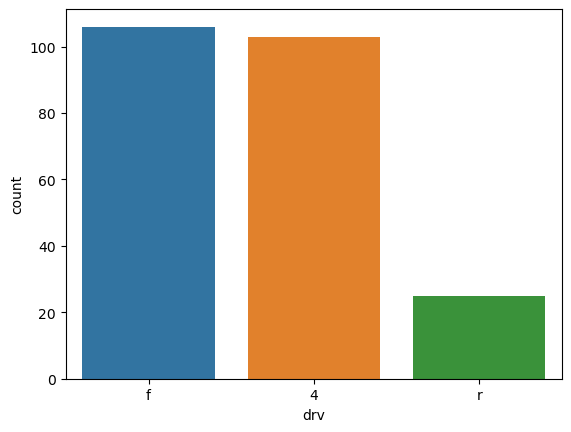

In [ ]:
# drv별로 카운트 출력
import pandas as pd
import seaborn as sns

mpg = pd.read_csv('mpg.csv')
df_mpg = mpg.groupby('drv',as_index=False).agg(n = ('drv','count'))
sns.barplot(data=df_mpg, x='drv',y='n',hue='drv')
# 카운트는 countplot으로도 가능하다
sns.countplot(data=mpg, x='drv',order=['4','f','r'],hue='drv') # 4륜, 전륜, 후륜 순서대로 카운트 그래프를 출력
# 이런 표현도 가능. drv에 제일 많은변수 순서대로 
sns.countplot(data=mpg, x='drv',order = mpg['drv'].value_counts().index, hue='drv')

<Axes: xlabel='category', ylabel='n'>

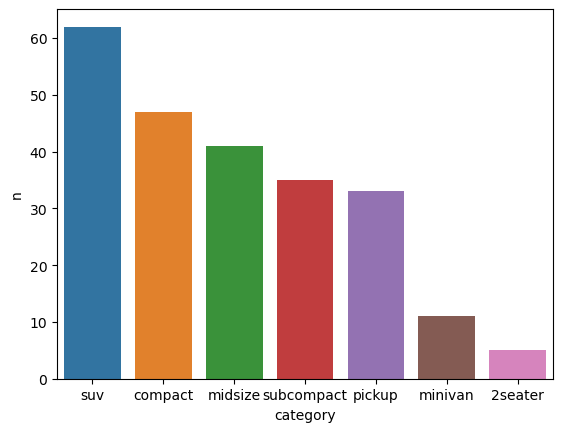

In [ ]:
# p211 혼자서해보기.
import pandas as pd
import seaborn as sns
mpg = pd.read_csv('mpg.csv')

# Q1. 어떤 회사의 'suv' 도시연비가 높은지 알고싶다. 'suv'차종을 대상으로 'cty'도시연비 평균이 가장 높은 회사 다섯곳을 막대그래프로 표현하라
df_mpg = mpg.query("category == 'suv'").groupby('manufacturer').agg(mean_cty=('cty','mean')).sort_values('mean_cty',ascending=False).head(5)
sns.barplot(data=df_mpg, x='manufacturer',y='mean_cty',hue='manufacturer')

# Q2. 전체 자동차중 어떤 차종(category)이 가장 많은지 알려고한다.  자동차 종류별 빈도를 표현한 막대그래프. 단 빈도가 높은 순서대로 정렬
df_mpg2 = mpg.groupby('category').agg(n = ('category','count')).sort_values('n',ascending=False)
sns.barplot(data=df_mpg2, x='category',y='n', hue='category')
# 이 방법도 가능 : sns.countplot(data=mpg, x='category', order= mpg['category'].value_counts().index, hue='category')


# Line chart (선 그래프) : 데이터의 시간에 따른 변화

In [ ]:
# 08-4. 선 그래프 - 시간에 따라 변화하는 데이터 표현
